In [2]:
install.packages("RSQLite", repos="https://cloud.r-project.org")
install.packages("DBI", repos="https://cloud.r-project.org")
install.packages("sqldf", repos="https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘chron’




In [3]:
library(DBI)
library(RSQLite)
library(sqldf)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”


In [4]:
getwd()
list.files()

[1] "/content"

[1] "app_events_cleaned.csv" "complaints_cleaned.csv" "customers_cleaned.csv" 
 [4] "deliveries_cleaned.csv" "drivers_cleaned.csv"    "hubs_cleaned.csv"      
 [7] "incidents_cleaned.csv"  "northstar.db"           "orders_cleaned.csv"    
[10] "sample_data"            "vehicles_cleaned.csv"

In [5]:
list.files()

[1] "app_events_cleaned.csv" "complaints_cleaned.csv" "customers_cleaned.csv" 
 [4] "deliveries_cleaned.csv" "drivers_cleaned.csv"    "hubs_cleaned.csv"      
 [7] "incidents_cleaned.csv"  "northstar.db"           "orders_cleaned.csv"    
[10] "sample_data"            "vehicles_cleaned.csv"

In [6]:
customers <- read.csv("customers_cleaned.csv")
head(customers)
nrow(customers)


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
2,C0002,61,Airport,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
3,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,,Active
4,C0004,75,Central,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
5,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
6,C0006,41,West,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


[1] 650

In [7]:
library(DBI)
library(RSQLite)

db_conn <- dbConnect(RSQLite::SQLite(), "northstar.db")
dbWriteTable(db_conn, "customers", customers, overwrite = TRUE)
dbListTables(db_conn)

[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"

In [8]:
packages <- c("RSQLite", "DBI", "tidyverse", "ggplot2")

installed <- rownames(installed.packages())
for (p in packages) {
  if (!(p %in% installed)) {
    install.packages(p, repos = "https://cloud.r-project.org")
  }
}

cat("Loading libraries...\n")
library(RSQLite)
library(DBI)
library(tidyverse)
library(ggplot2)
cat("Libraries loaded!\n\n")

data_path <- ""

cat("Creating database connection...\n")
db_conn <- dbConnect(RSQLite::SQLite(), "northstar.db")
cat("Database connection created!\n\n")

cat("Loading CSV files into database...\n")

customers <- read.csv(paste0(data_path, "customers_cleaned.csv"))
dbWriteTable(db_conn, "customers", customers, overwrite = TRUE)
cat("Customers table created (", nrow(customers), " rows)\n", sep="")

drivers <- read.csv(paste0(data_path, "drivers_cleaned.csv"))
dbWriteTable(db_conn, "drivers", drivers, overwrite = TRUE)
cat("Drivers table created (", nrow(drivers), " rows)\n", sep="")

vehicles <- read.csv(paste0(data_path, "vehicles_cleaned.csv"))
dbWriteTable(db_conn, "vehicles", vehicles, overwrite = TRUE)
cat("Vehicles table created (", nrow(vehicles), " rows)\n", sep="")

orders <- read.csv(paste0(data_path, "orders_cleaned.csv"))
dbWriteTable(db_conn, "orders", orders, overwrite = TRUE)
cat("Orders table created (", nrow(orders), " rows)\n", sep="")

deliveries <- read.csv(paste0(data_path, "deliveries_cleaned.csv"))
dbWriteTable(db_conn, "deliveries", deliveries, overwrite = TRUE)
cat("Deliveries table created (", nrow(deliveries), " rows)\n", sep="")

incidents <- read.csv(paste0(data_path, "incidents_cleaned.csv"))
dbWriteTable(db_conn, "incidents", incidents, overwrite = TRUE)
cat("Incidents table created (", nrow(incidents), " rows)\n", sep="")

complaints <- read.csv(paste0(data_path, "complaints_cleaned.csv"))
dbWriteTable(db_conn, "complaints", complaints, overwrite = TRUE)
cat("Complaints table created (", nrow(complaints), " rows)\n", sep="")

app_events <- read.csv(paste0(data_path, "app_events_cleaned.csv"))
dbWriteTable(db_conn, "app_events", app_events, overwrite = TRUE)
cat("App Events table created (", nrow(app_events), " rows)\n", sep="")

hubs <- read.csv(paste0(data_path, "hubs_cleaned.csv"))
dbWriteTable(db_conn, "hubs", hubs, overwrite = TRUE)
cat("Hubs table created (", nrow(hubs), " rows)\n", sep="")

cat("\nALL TABLES CREATED SUCCESSFULLY!\n\n")
cat("Tables in database:\n")
print(dbListTables(db_conn))
cat("\nDATABASE SETUP COMPLETE!\n")

Loading libraries...


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Libraries loaded!

Creating database connection...
Database connection created!

Loading CSV files into database...
Customers table created (650 rows)
Drivers table created (170 rows)
Vehicles table created (120 rows)
Orders table created (1250 rows)
Deliveries table created (950 rows)
Incidents table created (280 rows)
Complaints table created (320 rows)
App Events table created (640 rows)
Hubs table created (8 rows)

ALL TABLES CREATED SUCCESSFULLY!

Tables in database:
[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"  

DATABASE SETUP COMPLETE!


In [9]:
dbListTables(db_conn)


[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"

In [10]:
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)

db_conn <- dbConnect(RSQLite::SQLite(), "northstar.db")

delivery_duration_sql <- "
  SELECT
    d.delivery_id,
    d.dispatch_time,
    d.delivery_completed_at,
    CAST(
      (JULIANDAY(d.delivery_completed_at) - JULIANDAY(d.dispatch_time)) * 24 * 60
      AS INTEGER
    ) AS delivery_minutes
  FROM deliveries d
  WHERE d.delivery_completed_at IS NOT NULL
    AND d.dispatch_time IS NOT NULL;
"

delivery_duration <- dbGetQuery(db_conn, delivery_duration_sql)

head(delivery_duration)
summary(delivery_duration$delivery_minutes)

,delivery_id,dispatch_time,delivery_completed_at,delivery_minutes
,<chr>,<chr>,<chr>,<int>
1,DL00001,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,1328
2,DL00002,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,-66
3,DL00003,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,66
4,DL00004,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,1439
5,DL00005,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,242
6,DL00006,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,1711


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
 -132.0   176.0   424.0   572.3   878.5  2607.0      19 

In [11]:
complaints_status_sql <- "
  SELECT
    d.delivery_status,
    COUNT(DISTINCT c.complaint_id) AS complaint_count
  FROM deliveries d
  JOIN orders o
    ON d.order_id = o.order_id
  JOIN complaints c
    ON o.order_id = c.order_id
  GROUP BY d.delivery_status
  ORDER BY complaint_count DESC;
"

complaints_status <- dbGetQuery(db_conn, complaints_status_sql)
print(complaints_status)


  delivery_status complaint_count
1          OnTime             149
2         Delayed              48
3          Failed              35


In [12]:
driver_delay_sql <- "
  SELECT
    d.driver_id,
    AVG(
      (JULIANDAY(delivery_completed_at) - JULIANDAY(dispatch_time)) * 24 * 60
    ) AS avg_delay_minutes
  FROM deliveries d
  WHERE delivery_completed_at IS NOT NULL
    AND dispatch_time IS NOT NULL
  GROUP BY d.driver_id
  ORDER BY avg_delay_minutes DESC;
"

driver_delay <- dbGetQuery(db_conn, driver_delay_sql)
head(driver_delay)

,driver_id,avg_delay_minutes
,<chr>,<dbl>
1,D063,1303.751
2,D062,1261.362
3,D040,1124.622
4,D023,1117.948
5,D055,1109.523
6,D057,1068.542


In [13]:
inconsistencies_sql <- "
  SELECT
    d.delivery_id,
    d.delivery_status,
    o.order_id,
    COUNT(DISTINCT c.complaint_id) AS complaints_for_completed
  FROM deliveries d
  JOIN orders o
    ON d.order_id = o.order_id
  JOIN complaints c
    ON o.order_id = c.order_id
  WHERE d.delivery_status = 'Completed'
  GROUP BY d.delivery_id, d.delivery_status, o.order_id
  HAVING complaints_for_completed > 0
  ORDER BY complaints_for_completed DESC;
"

inconsistencies <- dbGetQuery(db_conn, inconsistencies_sql)
head(inconsistencies)
nrow(inconsistencies)

delivery_id,delivery_status,order_id,complaints_for_completed
<chr>,<chr>,<chr>,<lgl>


[1] 0

In [14]:
packages <- c("RSQLite", "DBI", "tidyverse", "ggplot2", "sqldf")

installed <- rownames(installed.packages())
for (p in packages) {
  if (!(p %in% installed)) {
    install.packages(p, repos = "https://cloud.r-project.org")
  }
}

library(RSQLite)
library(DBI)
library(tidyverse)
library(ggplot2)
library(sqldf)

cat("Libraries loaded!\n")

Libraries loaded!


Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


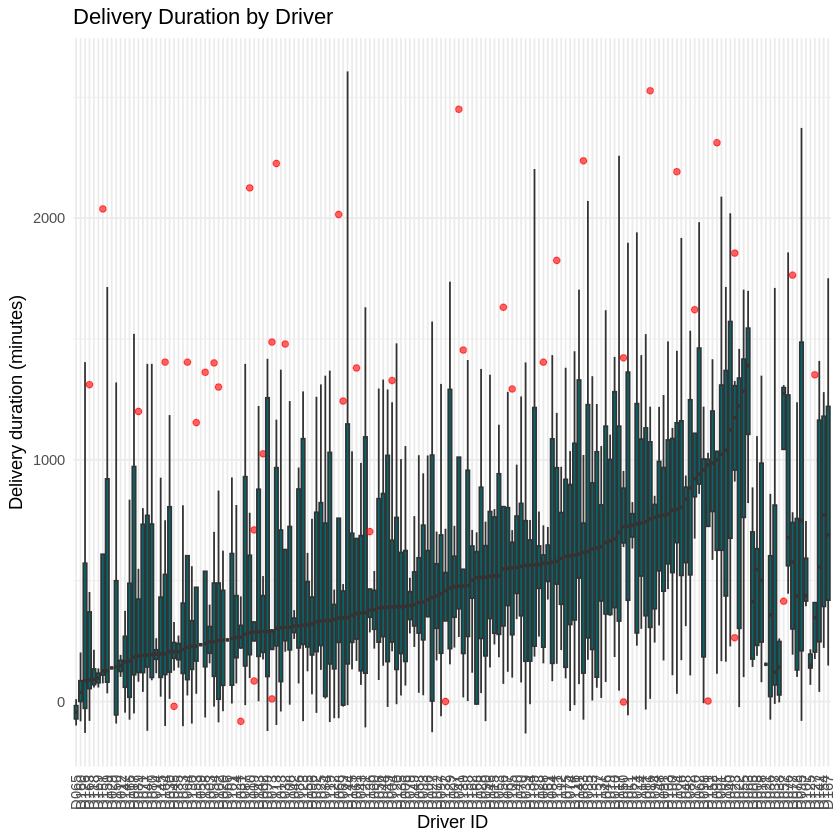

In [15]:
duration_by_driver_sql <- "
  SELECT
    d.driver_id,
    CAST(
      (JULIANDAY(d.delivery_completed_at) - JULIANDAY(d.dispatch_time)) * 24 * 60
      AS INTEGER
    ) AS delivery_minutes
  FROM deliveries d
  WHERE d.delivery_completed_at IS NOT NULL
    AND d.dispatch_time IS NOT NULL;
"

duration_by_driver <- dbGetQuery(db_conn, duration_by_driver_sql)

ggplot(duration_by_driver,
       aes(x = reorder(driver_id, delivery_minutes, FUN = median),
           y = delivery_minutes)) +
  geom_boxplot(fill = '#01696f', outlier.color = 'red', outlier.alpha = 0.6) +
  labs(
    title = 'Delivery Duration by Driver',
    x = 'Driver ID',
    y = 'Delivery duration (minutes)'
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

Warning message:
“Removed 19 rows containing non-finite outside the scale range (`stat_bin()`).”


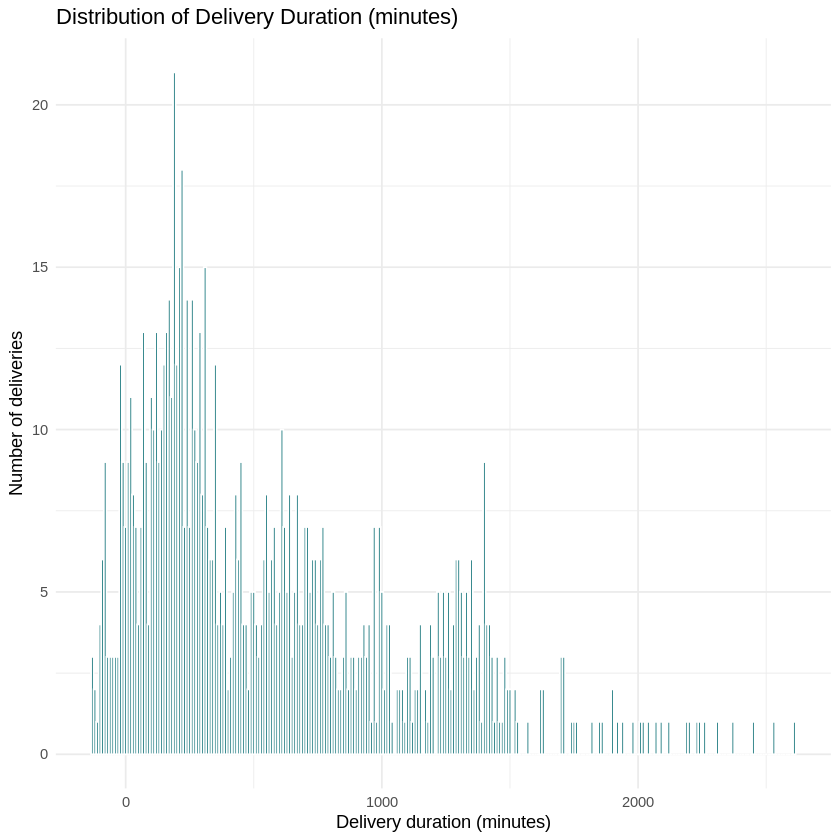

In [16]:
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)

db_conn <- dbConnect(RSQLite::SQLite(), "northstar.db")

duration_sql <- "
  SELECT
    d.delivery_id,
    d.dispatch_time,
    d.delivery_completed_at,
    CAST(
      (JULIANDAY(d.delivery_completed_at) - JULIANDAY(d.dispatch_time)) * 24 * 60
      AS INTEGER
    ) AS delivery_minutes
  FROM deliveries d
  WHERE d.delivery_completed_at IS NOT NULL
    AND d.dispatch_time IS NOT NULL;
"

delivery_duration <- dbGetQuery(db_conn, duration_sql)

ggplot(delivery_duration, aes(x = delivery_minutes)) +
  geom_histogram(binwidth = 10, fill = '#01696f', color = 'white') +
  labs(
    title = 'Distribution of Delivery Duration (minutes)',
    x = 'Delivery duration (minutes)',
    y = 'Number of deliveries'
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_point()`).”


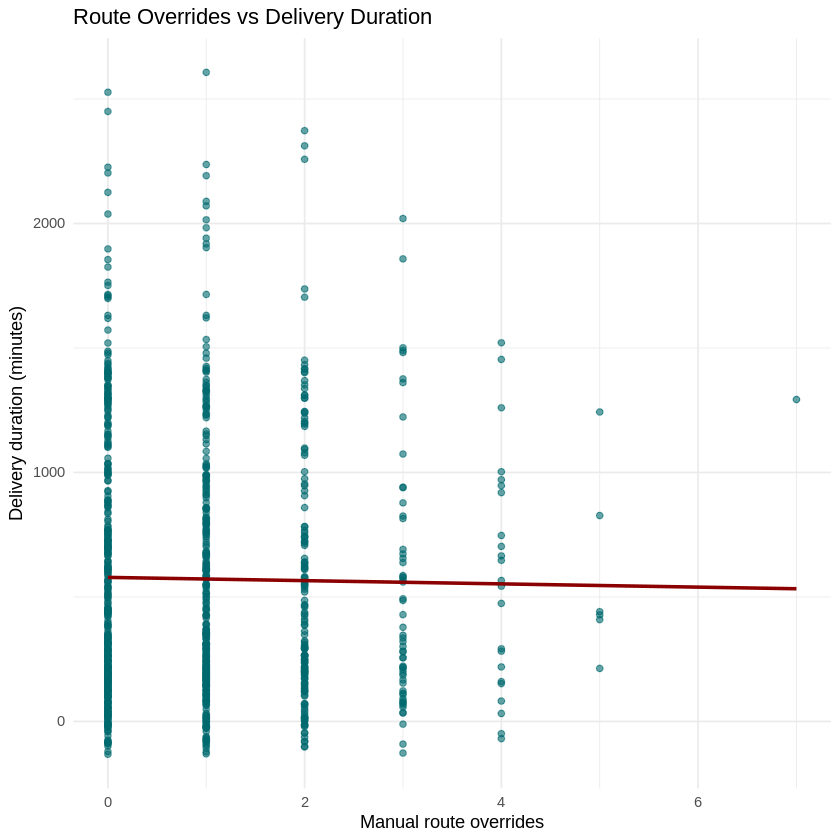

In [24]:
overrides_sql <- "
  SELECT
    d.delivery_id,
    d.manual_route_override_count,
    CAST(
      (JULIANDAY(d.delivery_completed_at) - JULIANDAY(d.dispatch_time)) * 24 * 60
      AS INTEGER
    ) AS delivery_minutes
  FROM deliveries d
  WHERE d.delivery_completed_at IS NOT NULL
    AND d.dispatch_time IS NOT NULL
    AND d.manual_route_override_count IS NOT NULL;
"

overrides_data <- dbGetQuery(db_conn, overrides_sql)

ggplot(overrides_data,
       aes(x = manual_route_override_count,
           y = delivery_minutes)) +
  geom_point(alpha = 0.6, color = '#01696f') +
  geom_smooth(method = 'lm', se = FALSE, color = 'darkred') +
  labs(
    title = 'Route Overrides vs Delivery Duration',
    x = 'Manual route overrides',
    y = 'Delivery duration (minutes)'
  ) +
  theme_minimal()

In [26]:
ls()

[1] "app_events"             "complaints"             "complaints_status"     
 [4] "complaints_status_sql"  "customers"              "data_path"             
 [7] "db_conn"                "deliveries"             "delivery_duration"     
[10] "delivery_duration_sql"  "driver_delay"           "driver_delay_sql"      
[13] "drivers"                "duration_by_driver"     "duration_by_driver_sql"
[16] "duration_sql"           "hubs"                   "incidents"             
[19] "inconsistencies"        "inconsistencies_sql"    "installed"             
[22] "orders"                 "overrides_data"         "overrides_sql"         
[25] "p"                      "packages"               "ratings_data"          
[28] "ratings_sql"            "vehicles"

In [27]:
if (exists("deliveries")) colnames(deliveries)
if (exists("orders")) colnames(orders)
if (exists("customers")) colnames(customers)
if (exists("complaints")) colnames(complaints)

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "customer_id"          "age"                  "home_zone"           
[4] "customer_type"        "signup_date"          "loyalty_score"       
[7] "app_engagement_score" "preferred_channel"    "account_status"

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

In [29]:
colnames(orders)

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

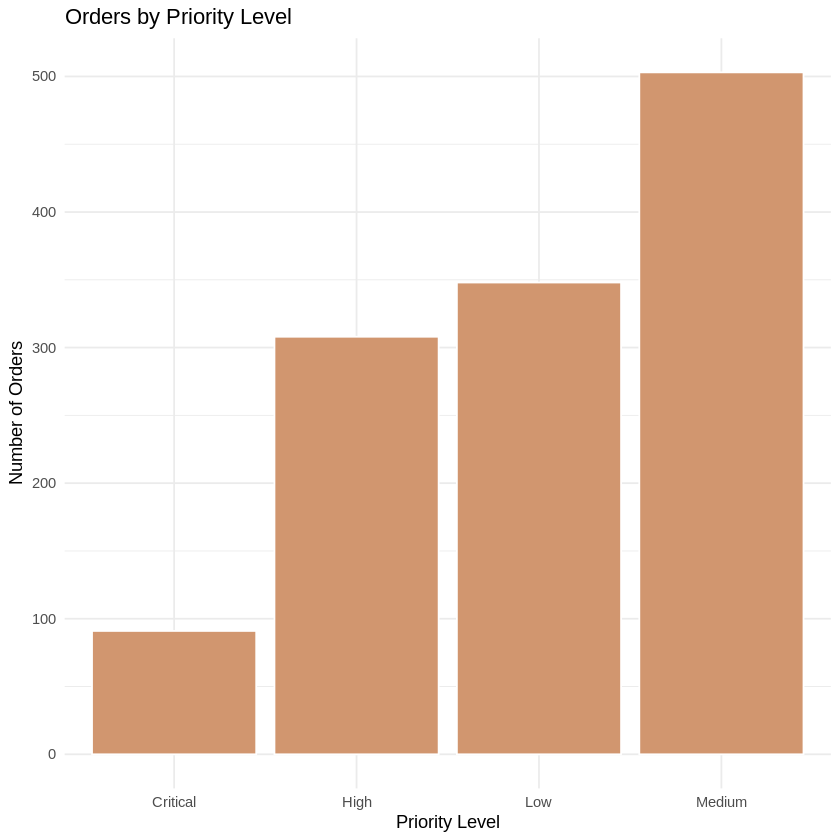

In [30]:
library(ggplot2)

ggplot(orders, aes(x = factor(priority_level))) +
  geom_bar(fill = "#D1966F", color = "white") +
  labs(
    title = "Orders by Priority Level",
    x = "Priority Level",
    y = "Number of Orders"
  ) +
  theme_minimal()

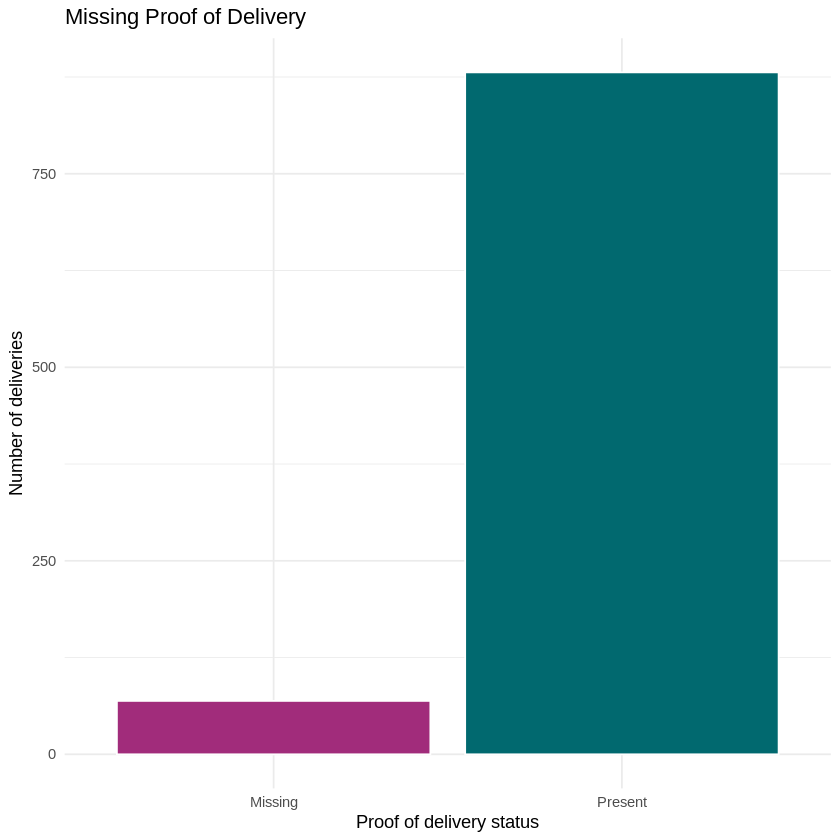

In [31]:
pod_sql <- "
  SELECT
    CASE
      WHEN proof_of_completion_missing = 1 THEN 'Missing'
      ELSE 'Present'
    END AS pod_status,
    COUNT(*) AS delivery_count
  FROM deliveries
  GROUP BY pod_status;
"

pod_data <- dbGetQuery(db_conn, pod_sql)

ggplot(pod_data,
       aes(x = pod_status,
           y = delivery_count,
           fill = pod_status)) +
  geom_col(color = 'white') +
  scale_fill_manual(values = c('Present' = '#01696f', 'Missing' = '#a12c7b')) +
  labs(
    title = 'Missing Proof of Delivery',
    x = 'Proof of delivery status',
    y = 'Number of deliveries'
  ) +
  theme_minimal() +
  theme(legend.position = 'none')